In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

## Reading in rds file using rpy2
This needs to be done in interactive session with the `load R` module command.

In [2]:
# Import rpy2 modules for R interoperability
import rpy2.robjects as robjects
from rpy2.robjects import r
import rpy2.robjects.packages as rpackages
import rpy2.robjects.vectors as rvectors
import rpy2.robjects.numpy2ri
import rpy2.robjects.pandas2ri
rpy2.robjects.__version__

'3.6.3'

In [3]:
# Read .rds file into pandas DataFrame
rds_path = '/nfs/turbo/umms-hammou/mrabbani/DATA_STORAGE/ATAC-processed/Tim_Parnell_analysis/Mashiat_analysis/MDI_downloads/new_mdi/protAtacTss.gcrz_obs.rds'

# Load R's readRDS function
readRDS = robjects.r['readRDS']
r_obj = readRDS(rds_path)

# Convert to pandas DataFrame
df = rpy2.robjects.pandas2ri.rpy2py(r_obj)
df.head()

,chrom,start0,end1,included,gc,gc_z,txn,stgm,hic,26104X2-MESC,...,early_RS,int_RS,late_RS,earliest_ES,early_ES,int_ES,late_ES,round,elong,stageType
1,chr1,0,1000,0,0.0,-7.246514,-3.0,NaN,NaN,2.608547,...,1.765159,0.026496,2.806114,1.620047,2.328808,1.658846,2.773824,1.610113,1.926831,-0.316718
2,chr1,1000,2000,0,0.0,-7.246514,-3.0,NaN,NaN,2.608547,...,1.765159,0.026496,2.806114,1.620047,2.328808,1.658846,2.773824,1.610113,1.926831,-0.316718
3,chr1,2000,3000,0,0.0,-7.246514,-3.0,NaN,NaN,2.608547,...,1.765159,0.026496,2.806114,1.620047,2.328808,1.658846,2.773824,1.610113,1.926831,-0.316718
4,chr1,3000,4000,0,0.0,-7.246514,-3.0,NaN,NaN,2.608547,...,1.765159,0.026496,2.806114,1.620047,2.328808,1.658846,2.773824,1.610113,1.926831,-0.316718
5,chr1,4000,5000,0,0.0,-7.246514,-3.0,NaN,NaN,2.608547,...,1.765159,0.026496,2.806114,1.620047,2.328808,1.658846,2.773824,1.610113,1.926831,-0.316718


In [4]:
df.rename(columns={'start0':'start', 'end1':'end'}, inplace=True)
df_gc = df[['chrom', 'start', 'end', 'mESC','early_RS', 'int_RS', 'late_RS', 
        'earliest_ES', 'early_ES', 'int_ES','late_ES']]

In [6]:
df_gc.head()

,chrom,start,end,mESC,early_RS,int_RS,late_RS,earliest_ES,early_ES,int_ES,late_ES
1,chr1,0,1000,3.063994,1.765159,0.026496,2.806114,1.620047,2.328808,1.658846,2.773824
2,chr1,1000,2000,3.063994,1.765159,0.026496,2.806114,1.620047,2.328808,1.658846,2.773824
3,chr1,2000,3000,3.063994,1.765159,0.026496,2.806114,1.620047,2.328808,1.658846,2.773824
4,chr1,3000,4000,3.063994,1.765159,0.026496,2.806114,1.620047,2.328808,1.658846,2.773824
5,chr1,4000,5000,3.063994,1.765159,0.026496,2.806114,1.620047,2.328808,1.658846,2.773824


In [5]:
# Load compartment file
compartment_path = '/nfs/turbo/umms-hammou/minjilab/juicer/work_mm10_backup/all_samples_combined/mega/aligned/compartments/flipped_compartments_250000_pc1_mm39.bedGraph'
comp_df = pd.read_csv(compartment_path, sep='\t', header=None, names=['chrom', 'start', 'end', 'score'])

comp_df.head()

,chrom,start,end,score
0,chr1,3069991,3320223,0.003926
1,chr1,3320223,3570223,0.004842
2,chr1,3570223,3820223,0.005309
3,chr1,3820223,4070223,0.005365
4,chr1,4070223,4320223,0.008476


In [ ]:
# Merge GC residual bins with compartment scores for each chromosome

result_list = []
for chrom in df_gc['chrom'].unique():
    # Subset GC residual bins for this chromosome
    df_chr = df_gc[df_gc['chrom'] == chrom].copy()
    # Subset compartment regions for this chromosome
    comp_chr = comp_df[comp_df['chrom'] == chrom].copy()
    comp_chr.sort_values(by='start', inplace=True)
    # For each GC bin, find the compartment region whose start is <= bin start
    # merge_asof: for each GC bin, find the compartment region whose start is <= bin start
    merged = pd.merge_asof(df_chr, comp_chr, on='start', direction='backward', suffixes=('', '_comp'))
    # Only keep bins where bin start < compartment end (i.e., bin is within compartment region)
    merged = merged[merged['start'] < merged['end']]
    result_list.append(merged)

# Concatenate results for all chromosomes into a single DataFrame
df_merged = pd.concat(result_list, ignore_index=True)

# Assign compartment score and label to each GC bin
df_merged['compartment_score'] = df_merged['score']
df_merged['compartment'] = df_merged['compartment_score'].apply(lambda x: 'A' if x > 0 else ('B' if x < 0 else None))

# Save merged DataFrame to CSV for downstream analysis and reproducibility
df_merged.to_csv('analysis_data/mm39_merged_gc_resids_with_compartment_scores.csv')

## Start here for processed data

In [ ]:
# remove mm39_ for mm10 analysis
df_merged = pd.read_csv('analysis_data/mm39_merged_gc_resids_with_compartment_scores.csv', index_col=0)
# Melt the GC columns for plotting
gc_cols = [col for col in df_merged.columns if col not in ['chrom', 'start', 'end', 'chrom_comp', 'end_comp', 
                                                           'score', 'compartment_score', 'compartment']]

# Reshape the merged DataFrame from wide to long format for plotting
# Each row will represent a single GC residual value for a specific stage and bin

melted = df_merged.melt(
    id_vars=['chrom', 'start', 'end', 'compartment'],  # Columns to keep fixed
    value_vars=gc_cols,                                # Columns to melt (GC residuals for each stage)
    var_name='stage',                                  # Name for the melted variable column
    value_name='gc_resid'                              # Name for the melted value column
)

# Convert gc_resid values to numeric, coercing errors to NaN
melted['gc_resid'] = pd.to_numeric(melted['gc_resid'], errors='coerce')

# Filter out rows where compartment label is missing (only keep bins assigned to A or B)
melted = melted[melted['compartment'].notnull()]

/tmp/ipykernel_2946821/2999680750.py:2: DtypeWarning: Columns (12,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df_merged = pd.read_csv('analysis_data/mm39_merged_gc_resids_with_compartment_scores.csv', index_col=0)


In [ ]:
melted.head()

,chrom,start,end,compartment,stage,gc_resid
3000,chr1,3000000,3001000,A,mESC,3.063994
3001,chr1,3001000,3002000,A,mESC,3.063994
3002,chr1,3002000,3003000,A,mESC,3.063994
3003,chr1,3003000,3004000,A,mESC,3.063994
3004,chr1,3004000,3005000,A,mESC,3.063994


### Figure GC Resid by compartment

In [11]:
stages = ['early_RS', 'int_RS', 'late_RS', 'earliest_ES', 'early_ES', 'int_ES']

### Fig 6c

In [ ]:
def bootstrap_ci(data, n_boot=1000, ci=95, rng=None, sample_size=1000):
    # Convert input data to numpy array and drop NaN values
    data = np.array(data.dropna())
    # If no data, return NaNs for all outputs
    if len(data) == 0:
        return np.nan, np.nan, np.nan
    # Set up random number generator if not provided
    if rng is None:
        rng = np.random.default_rng(42)
    # Subsample data if it's larger than sample_size for speed
    if len(data) > sample_size:
        data = rng.choice(data, size=sample_size, replace=False)
    # Perform bootstrap: sample with replacement and compute median for each bootstrap
    boot_meds = [np.median(rng.choice(data, size=len(data), replace=True)) for _ in range(n_boot)]
    # Calculate lower and upper percentiles for confidence interval
    lower = np.percentile(boot_meds, (100-ci)/2)
    upper = np.percentile(boot_meds, 100-(100-ci)/2)
    # Return observed median and confidence interval bounds
    return np.median(data), lower, upper

# Compute medians and CIs for each group
obs_A_stats = [bootstrap_ci(melted[(melted['compartment'] == 'A') & (melted['stage'] == stage)]['gc_resid'], rng=rng) for stage in stages]
obs_B_stats = [bootstrap_ci(melted[(melted['compartment'] == 'B') & (melted['stage'] == stage)]['gc_resid'], rng=rng) for stage in stages]

# Unpack for plotting
medians_obs_A, lower_obs_A, upper_obs_A = zip(*obs_A_stats)
medians_obs_B, lower_obs_B, upper_obs_B = zip(*obs_B_stats)

# For expected, use the same approach for CIs
rng = np.random.default_rng(42)
exp_A_stats = [bootstrap_ci(pd.Series(rng.normal(0, 1, min(melted[(melted['compartment'] == 'A') & (melted['stage'] == stage)].shape[0], 1000))), rng=rng) for stage in stages]
exp_B_stats = [bootstrap_ci(pd.Series(rng.normal(0, 1, min(melted[(melted['compartment'] == 'B') & (melted['stage'] == stage)].shape[0], 1000))), rng=rng) for stage in stages]
medians_exp_A, lower_exp_A, upper_exp_A = zip(*exp_A_stats)
medians_exp_B, lower_exp_B, upper_exp_B = zip(*exp_B_stats)

In [15]:
# Calculate n for each group
n_obs_A = [melted[(melted['compartment'] == 'A') & (melted['stage'] == stage)]['gc_resid'].dropna().shape[0] for stage in stages]
n_obs_B = [melted[(melted['compartment'] == 'B') & (melted['stage'] == stage)]['gc_resid'].dropna().shape[0] for stage in stages]


/tmp/ipykernel_2946821/497497781.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([stage.replace('_', ' ') for stage in stages], fontsize=14)


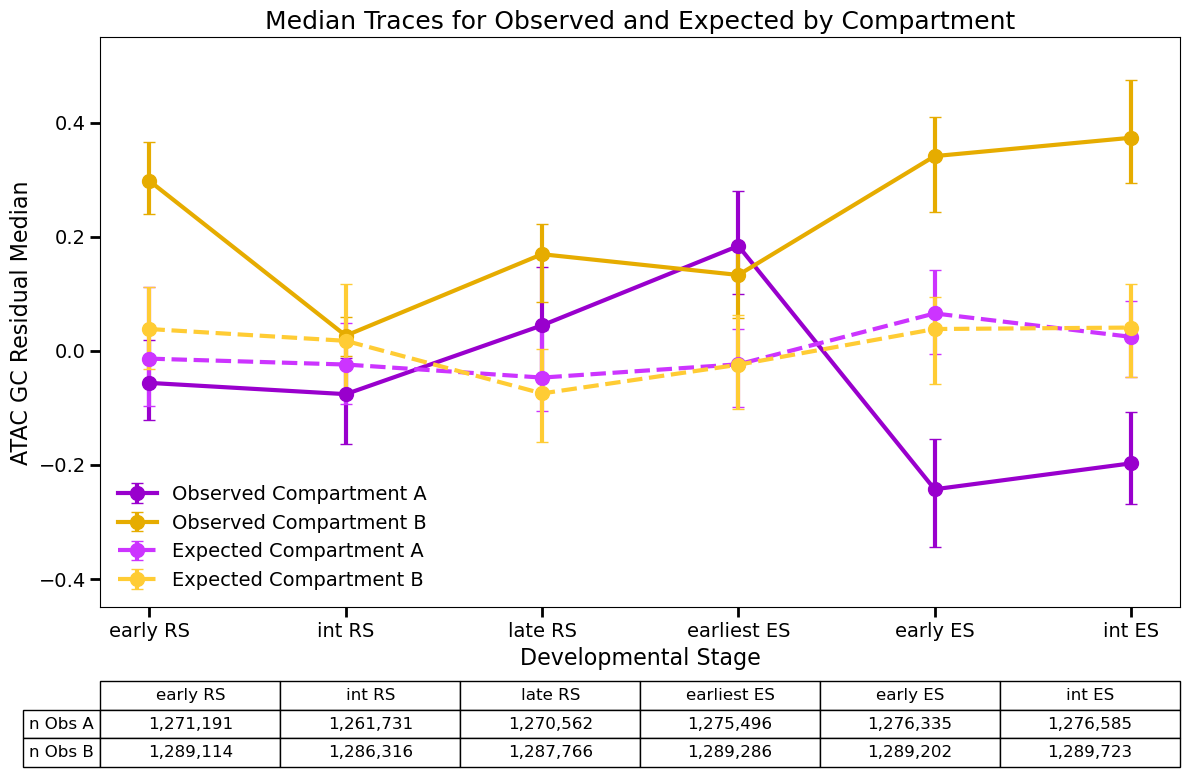

In [ ]:
# Plot median GC residuals for observed and expected values by compartment and stage, with error bars

fig, ax = plt.subplots(figsize=(12, 8))

# Plot observed medians and confidence intervals for Compartment A
ax.errorbar(
    stages, medians_obs_A,
    yerr=[np.array(medians_obs_A)-np.array(lower_obs_A), np.array(upper_obs_A)-np.array(medians_obs_A)],
    label='Observed Compartment A', color='#9900cd', linestyle='-', marker='o', capsize=4,
    lw=3, markersize=10
)
# Plot observed medians and confidence intervals for Compartment B
ax.errorbar(
    stages, medians_obs_B,
    yerr=[np.array(medians_obs_B)-np.array(lower_obs_B), np.array(upper_obs_B)-np.array(medians_obs_B)],
    label='Observed Compartment B', color='#e6ac00', linestyle='-', marker='o', capsize=4, lw=3, markersize=10
)

# Plot expected medians and confidence intervals for Compartment A (null distribution)
ax.errorbar(
    stages, medians_exp_A,
    yerr=[np.array(medians_exp_A)-np.array(lower_exp_A), np.array(upper_exp_A)-np.array(medians_exp_A)],
    label='Expected Compartment A', color='#cc34ff', linestyle='--', marker='o', capsize=4, alpha=1, lw=3, markersize=10
)
# Plot expected medians and confidence intervals for Compartment B (null distribution)
ax.errorbar(
    stages, medians_exp_B,
    yerr=[np.array(medians_exp_B)-np.array(lower_exp_B), np.array(upper_exp_B)-np.array(medians_exp_B)],
    label='Expected Compartment B', color='#ffcc34', linestyle='--', marker='o', capsize=4, alpha=1, lw=3, markersize=10
)

# Prepare table data showing sample sizes for each group and stage
table_data = [
    [f"{n:,}" for n in n_obs_A],
    [f"{n:,}" for n in n_obs_B]
]
row_labels = ["n Obs A", "n Obs B"]

# Add table below the x-axis to show sample sizes
table = ax.table(
    cellText=table_data,
    rowLabels=row_labels,
    colLabels=[stage.replace('_', ' ') for stage in stages],
    cellLoc='center',
    rowLoc='center',
    loc='bottom',
    bbox=[0, -0.28, 1, 0.15]  # [left, bottom, width, height]
)
table.auto_set_font_size(False)
table.set_fontsize(12)

# Set axis labels and title
ax.set_xlabel('Developmental Stage', fontsize=16)
ax.set_ylabel('ATAC GC Residual Median', fontsize=16)
ax.set_title('Median Traces for Observed and Expected by Compartment', fontsize=18)

# Add legend for the plot
#ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.legend(loc='best', fontsize=14, frameon=False)

# Customize tick parameters for better readability
ax.tick_params(axis='both', which='major', labelsize=14, width=2, length=7)
ax.tick_params(axis='both', which='minor', width=2, length=4)

# Set custom x-axis tick labels
ax.set_xticklabels([stage.replace('_', ' ') for stage in stages], fontsize=14)

# Set y-axis limits for the plot
ax.set_ylim(-.45, .55)
plt.tight_layout()

# Save figure to file and display
plt.savefig('figure_plots/final_figs/6c_compartment_median_traces_with_CI.png', dpi=300, bbox_inches='tight')
plt.show()

### Other analyses

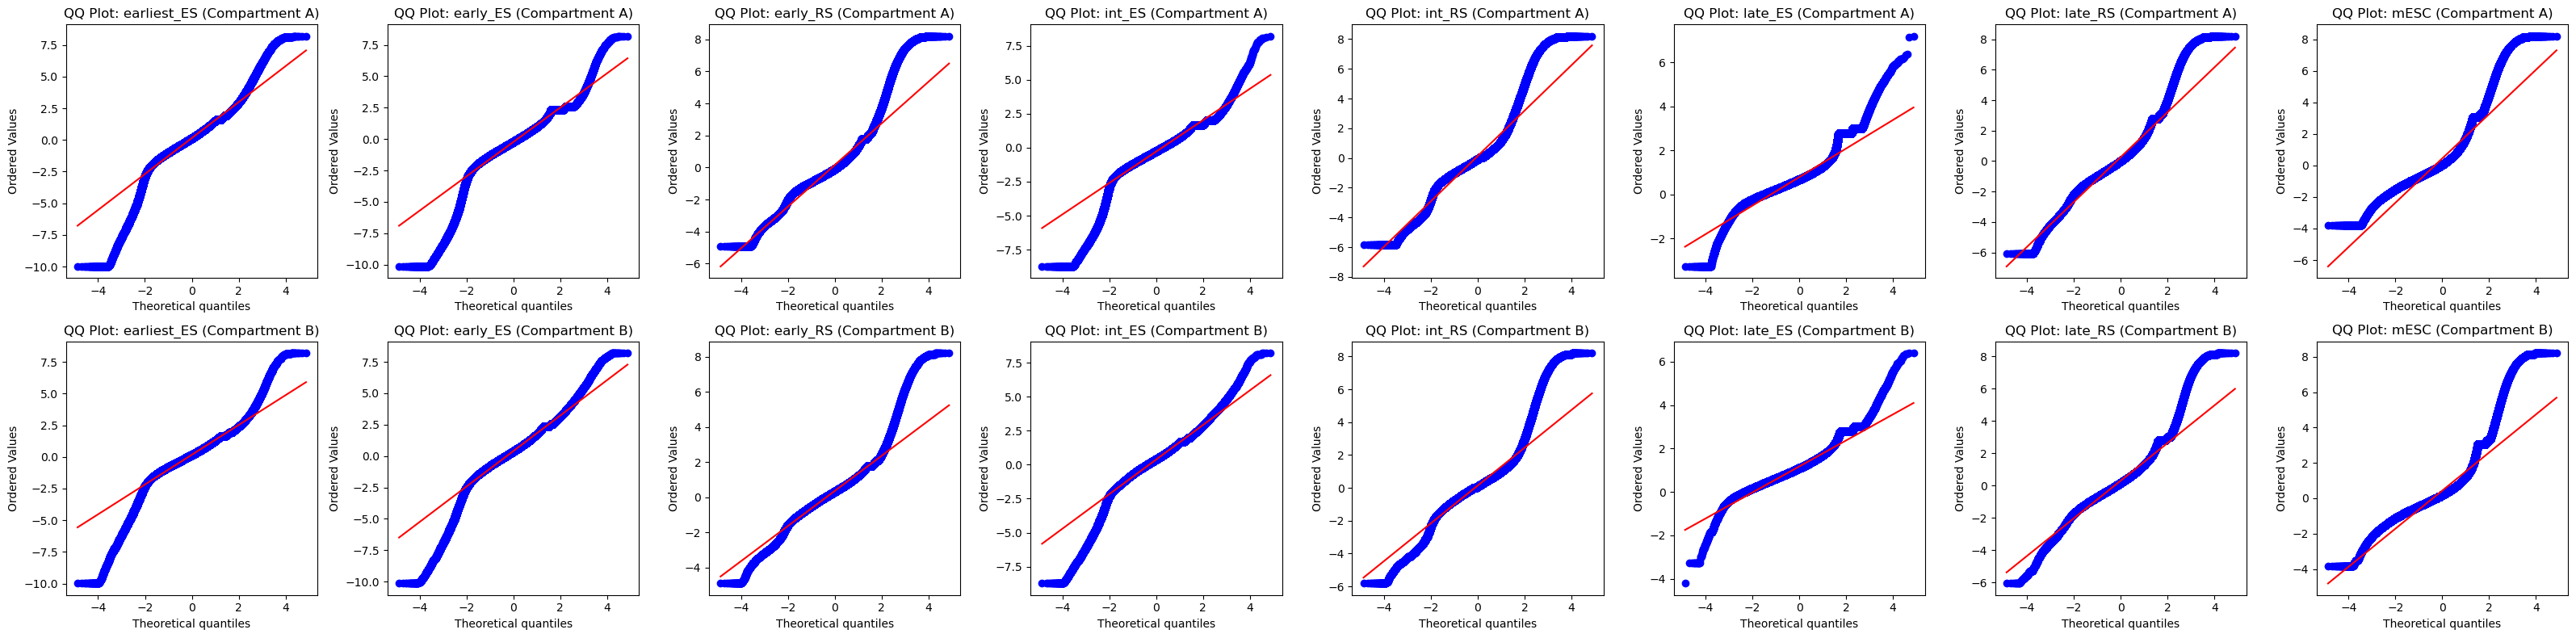

In [ ]:
# --- QQ plots for each stage and compartment ---
fig, axes = plt.subplots(2, len(stages), figsize=(4*len(stages), 8))
for i, comp in enumerate(['A', 'B']):
    data = melted[melted['compartment'] == comp]
    for j, stage in enumerate(stages):
        ax_qq = axes[i, j] if len(stages) > 1 else axes[i]
        stage_data = data[data['stage'] == stage]['gc_resid'].dropna()
        if len(stage_data) > 0:
            stats.probplot(stage_data, dist="norm", plot=ax_qq)
            ax_qq.set_title(f'QQ Plot: {stage} (Compartment {comp})')
        else:
            ax_qq.set_visible(False)
plt.tight_layout()
plt.savefig('figure_plots/5c_qqplots_validation_of_normal_background.png')
plt.show()